# 🎯 FaceCode – Emotion CNN Training Notebook

This notebook trains a custom CNN on the **FER2013** dataset to detect 7 emotions from 48×48 grayscale face images.

### What this notebook does (in order):
1. Checks GPU availability
2. Uploads and loads FER2013 dataset
3. Explores and visualises the data
4. Preprocesses and augments images
5. Builds the CNN architecture
6. Trains with callbacks (checkpoint, early stopping, LR scheduler)
7. Plots training curves
8. Evaluates per-class accuracy and confusion matrix
9. Saves and downloads `emotion_cnn.keras`

### Before you start:
- Go to **Runtime → Change runtime type → T4 GPU** (free on Colab)
- Download `fer2013.csv` from [Kaggle](https://www.kaggle.com/datasets/msambare/fer2013)
- Have the CSV ready to upload in Cell 2

**Expected training time:** ~10 min on T4 GPU | ~40 min on CPU

---
## Cell 1 – Check GPU and install dependencies

In [4]:
# ── Check GPU ──────────────────────────────────────────────────────────────
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU detected: {gpus[0].name}')
    print(f'   TensorFlow version: {tf.__version__}')
else:
    print('⚠️  No GPU detected – training will be slow (~40 min)')
    print('   Go to Runtime → Change runtime type → T4 GPU')

# ── Standard imports ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

print('\n✅ All imports successful')

⚠️  No GPU detected – training will be slow (~40 min)
   Go to Runtime → Change runtime type → T4 GPU

✅ All imports successful


---
## Cell 2 – Load and explore the dataset

FER2013 has 35,887 images across 7 emotion classes.
Each image is stored as a string of 2304 space-separated pixel values (48×48).

In [6]:
# ── Load CSV ───────────────────────────────────────────────────────────────
df = pd.read_csv("fer2013.csv")
print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst row preview:')
print(df.iloc[0])

# ── Emotion labels ─────────────────────────────────────────────────────────
EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
df['emotion_name'] = df['emotion'].map({i: e for i, e in enumerate(EMOTION_LABELS)})

# ── Class distribution ─────────────────────────────────────────────────────
print('\n📊 Class distribution:')
counts = df['emotion_name'].value_counts().reindex(EMOTION_LABELS)
for emotion, count in counts.items():
    bar = '█' * (count // 200)
    pct = count / len(df) * 100
    print(f'  {emotion:10} {count:5d} ({pct:4.1f}%)  {bar}')

# ── Split info ─────────────────────────────────────────────────────────────
print('\n📂 Dataset splits:')
for split, count in df['Usage'].value_counts().items():
    print(f'  {split:15} {count:5d} samples')

Dataset shape: (35887, 3)

Columns: ['emotion', 'pixels', 'Usage']

First row preview:
emotion                                                    0
pixels     70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
Usage                                               Training
Name: 0, dtype: object

📊 Class distribution:
  angry       4953 (13.8%)  ████████████████████████
  disgust      547 ( 1.5%)  ██
  fear        5121 (14.3%)  █████████████████████████
  happy       8989 (25.0%)  ████████████████████████████████████████████
  sad         6077 (16.9%)  ██████████████████████████████
  surprise    4002 (11.2%)  ████████████████████
  neutral     6198 (17.3%)  ██████████████████████████████

📂 Dataset splits:
  Training        28709 samples
  PublicTest       3589 samples
  PrivateTest      3589 samples


---
## Cell 4 – Visualise sample images

This shows 5 sample images per emotion class so you can see what the model learns from.

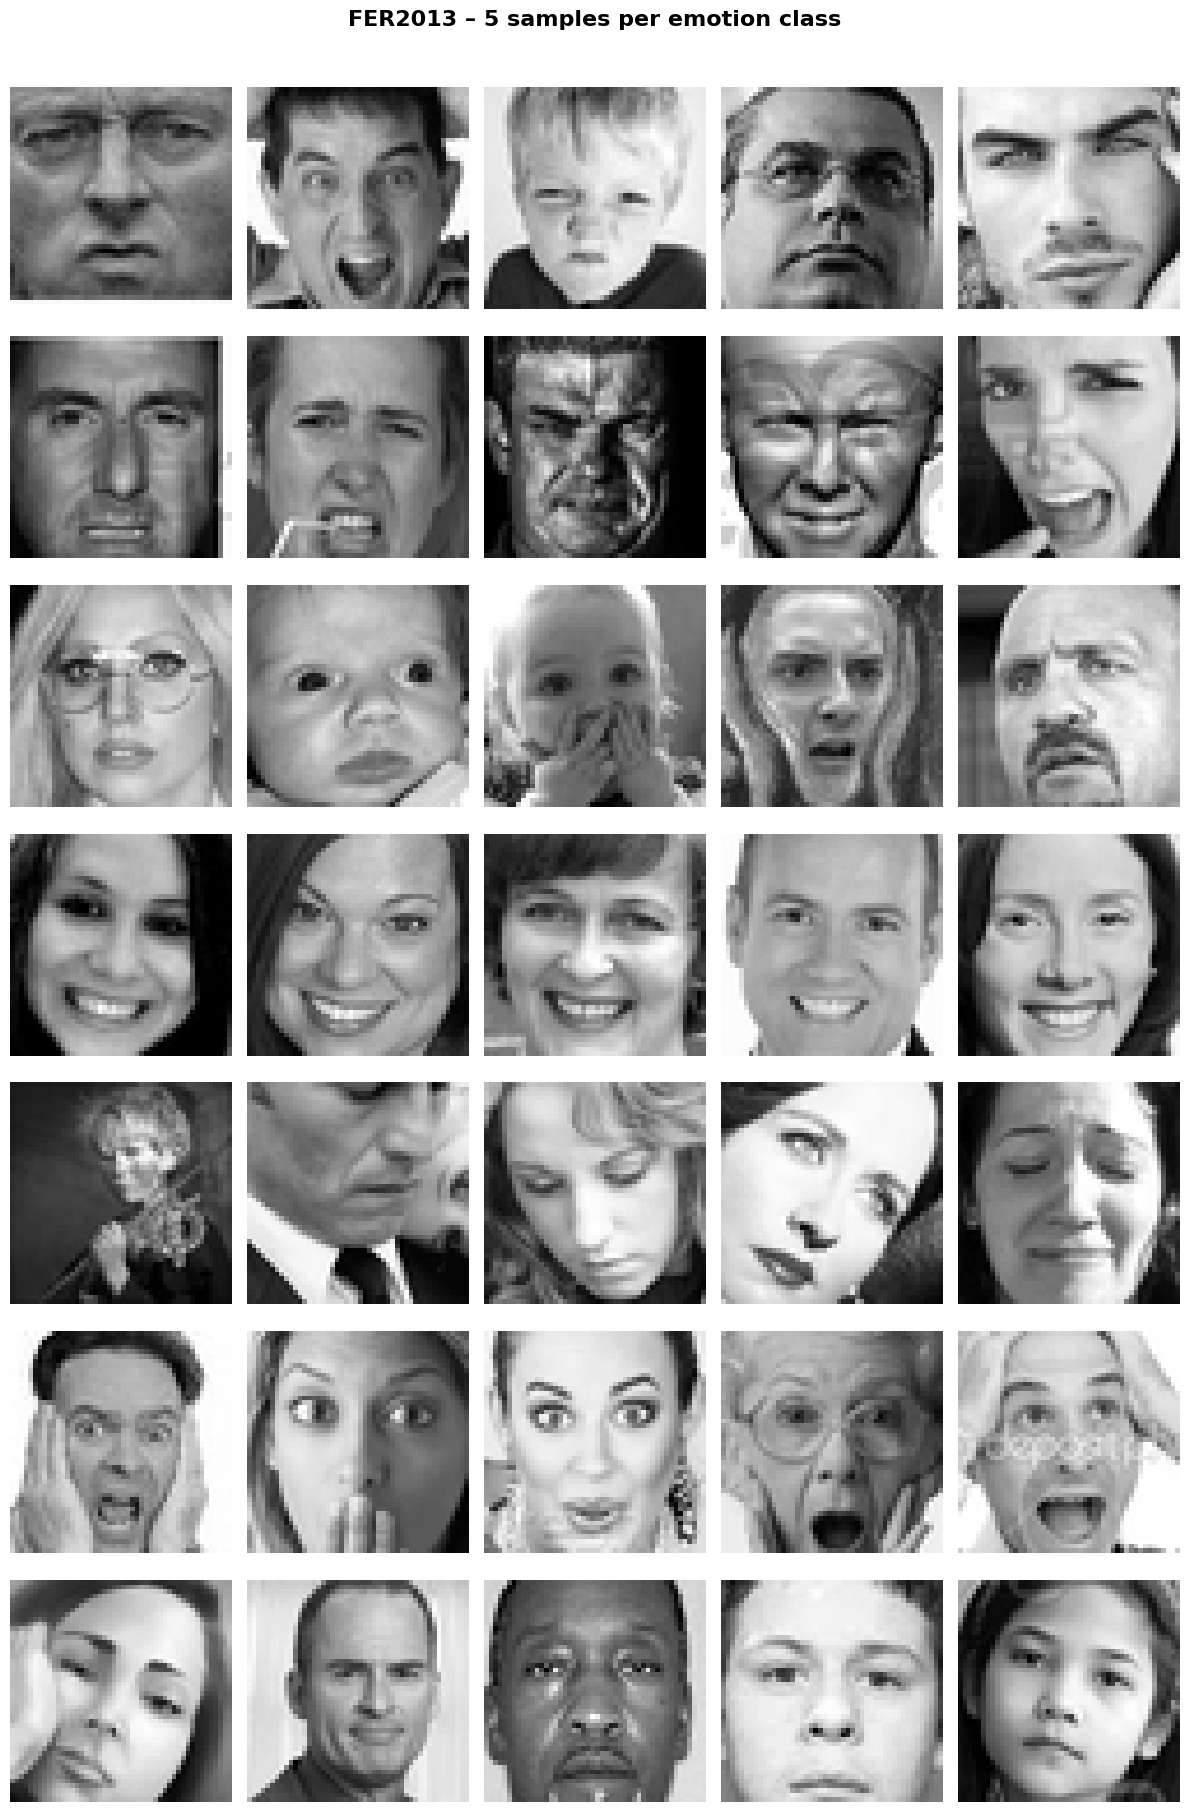

✅ Sample images visualised


In [7]:
def pixels_to_image(pixel_string):
    """Convert FER2013 pixel string to 48x48 numpy array."""
    return np.array(pixel_string.split(), dtype=np.uint8).reshape(48, 48)

fig, axes = plt.subplots(7, 5, figsize=(12, 18))
fig.suptitle('FER2013 – 5 samples per emotion class', fontsize=16, fontweight='bold', y=1.01)

for row_idx, emotion in enumerate(EMOTION_LABELS):
    emotion_df = df[df['emotion_name'] == emotion]
    samples = emotion_df.sample(min(5, len(emotion_df)), random_state=42)
    
    for col_idx, (_, sample) in enumerate(samples.iterrows()):
        img = pixels_to_image(sample['pixels'])
        ax = axes[row_idx][col_idx]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(emotion.upper(), fontsize=10, fontweight='bold', rotation=0,
                         labelpad=55, va='center')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Sample images visualised')

---
## Cell 5 – Preprocess images and create train/test splits

🔄 Preprocessing images (CLAHE + normalisation)...
   This may take 1-2 minutes...

✅ Preprocessing complete
   X_train shape: (28709, 48, 48, 1)  (264.6 MB)
   X_test  shape: (7178, 48, 48, 1)   (66.2 MB)
   y_train shape: (28709, 7)
   Pixel value range: [0.02, 1.00]


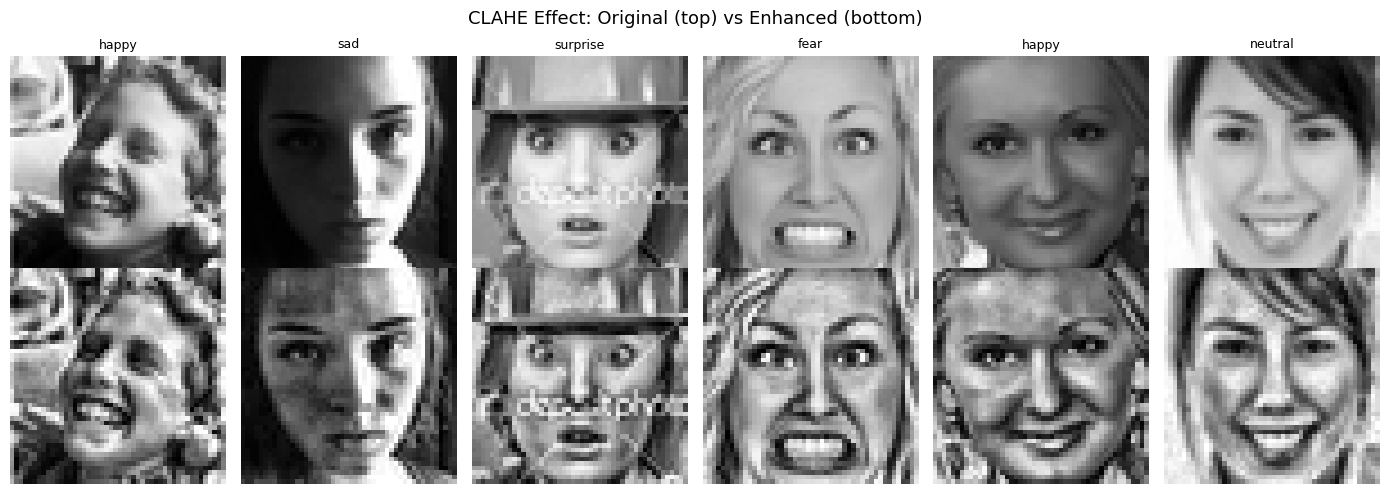

In [8]:
import cv2

def preprocess_with_clahe(pixel_string):
    """
    Parse pixel string → apply CLAHE contrast enhancement → normalise to 0-1.
    CLAHE (Contrast Limited Adaptive Histogram Equalisation) makes facial
    features more visible in low-light or low-contrast images.
    """
    img = np.array(pixel_string.split(), dtype=np.uint8).reshape(48, 48)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return img.astype(np.float32) / 255.0

print('🔄 Preprocessing images (CLAHE + normalisation)...')
print('   This may take 1-2 minutes...')

# Apply preprocessing to all rows
df['processed'] = df['pixels'].apply(preprocess_with_clahe)

# ── Train / Test split ─────────────────────────────────────────────────────
train_df = df[df['Usage'] == 'Training'].copy()
test_df  = df[df['Usage'].isin(['PublicTest', 'PrivateTest'])].copy()

# Stack into arrays
X_train = np.stack(train_df['processed'].values).reshape(-1, 48, 48, 1)
X_test  = np.stack(test_df['processed'].values).reshape(-1, 48, 48, 1)

y_train = to_categorical(train_df['emotion'].values, num_classes=7)
y_test  = to_categorical(test_df['emotion'].values,  num_classes=7)

print(f'\n✅ Preprocessing complete')
print(f'   X_train shape: {X_train.shape}  ({X_train.nbytes / 1e6:.1f} MB)')
print(f'   X_test  shape: {X_test.shape}   ({X_test.nbytes / 1e6:.1f} MB)')
print(f'   y_train shape: {y_train.shape}')
print(f'   Pixel value range: [{X_train.min():.2f}, {X_train.max():.2f}]')

# ── Visualise CLAHE effect ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('CLAHE Effect: Original (top) vs Enhanced (bottom)', fontsize=13)

sample_indices = np.random.choice(len(train_df), 6, replace=False)
for i, idx in enumerate(sample_indices):
    orig_str = train_df.iloc[idx]['pixels']
    orig_img = np.array(orig_str.split(), dtype=np.uint8).reshape(48, 48)
    enhanced = X_train[idx].reshape(48, 48)
    
    axes[0][i].imshow(orig_img, cmap='gray')
    axes[0][i].axis('off')
    axes[0][i].set_title(EMOTION_LABELS[train_df.iloc[idx]['emotion']], fontsize=9)
    
    axes[1][i].imshow(enhanced, cmap='gray')
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

---
## Cell 6 – Compute class weights

FER2013 is heavily imbalanced — 'happy' has ~8000 samples while 'disgust' has only ~400.
Without class weights, the model learns to predict 'happy'/'neutral' most of the time.
Class weights penalise the model more for getting rare emotions wrong.

⚖️  Class weights (higher = rarer class, penalised more):
  angry      count= 3995  weight= 1.03  ███
  disgust    count=  436  weight= 9.41  ████████████████████████████
  fear       count= 4097  weight= 1.00  ███
  happy      count= 7215  weight= 0.57  █
  sad        count= 4830  weight= 0.85  ██
  surprise   count= 3171  weight= 1.29  ███
  neutral    count= 4965  weight= 0.83  ██


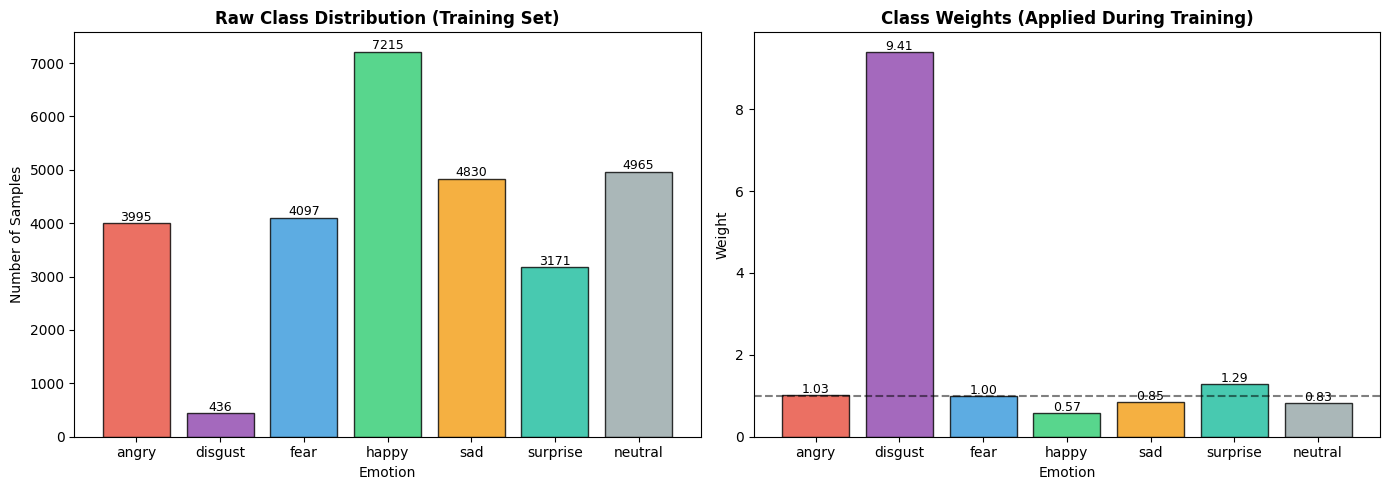

✅ Class weights computed


In [9]:
# ── Class weights ──────────────────────────────────────────────────────────
class_counts = y_train.sum(axis=0)
total_samples = class_counts.sum()
class_weights = {i: total_samples / (7 * class_counts[i]) for i in range(7)}

print('⚖️  Class weights (higher = rarer class, penalised more):')
for i, (emotion, count, weight) in enumerate(zip(
    EMOTION_LABELS, class_counts, class_weights.values()
)):
    bar = '█' * int(weight * 3)
    print(f'  {emotion:10} count={int(count):5d}  weight={weight:5.2f}  {bar}')

# ── Visualise class distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
colors = ['#e74c3c','#8e44ad','#3498db','#2ecc71','#f39c12','#1abc9c','#95a5a6']
axes[0].bar(EMOTION_LABELS, class_counts, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Raw Class Distribution (Training Set)', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Emotion')
for i, count in enumerate(class_counts):
    axes[0].text(i, count + 50, str(int(count)), ha='center', fontsize=9)

# Class weights
weight_vals = list(class_weights.values())
axes[1].bar(EMOTION_LABELS, weight_vals, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Class Weights (Applied During Training)', fontweight='bold')
axes[1].set_ylabel('Weight')
axes[1].set_xlabel('Emotion')
axes[1].axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='weight=1.0')
for i, w in enumerate(weight_vals):
    axes[1].text(i, w + 0.05, f'{w:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Class weights computed')

---
## Cell 7 – Build the CNN model

Architecture explanation:
- **4 convolutional blocks** — each learns increasingly complex facial features
  - Block 1 (32 filters): edges, basic gradients
  - Block 2 (64 filters): eye/mouth shapes
  - Block 3 (128 filters): facial feature combinations
  - Block 4 (256 filters): emotion-specific patterns
- **BatchNormalization** — stabilises training, acts as mild regularisation
- **GlobalAveragePooling** — replaces Flatten, reduces overfitting, fewer params
- **Dropout** — randomly disables neurons during training to prevent memorisation

In [10]:
def build_emotion_cnn(input_shape=(48, 48, 1), num_classes=7):
    """
    FaceCode Emotion CNN
    4-block convolutional network with GlobalAveragePooling head.
    ~1.2 million parameters – fast on CPU, very fast on GPU.
    """
    inputs = keras.Input(shape=input_shape, name='face_input')

    # ── Block 1: learns basic edges and gradients ──────────────────────────
    x = layers.Conv2D(32, 3, padding='same', activation='relu', name='conv1_1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu', name='conv1_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='pool1')(x)         # 48x48 → 24x24
    x = layers.Dropout(0.25, name='drop1')(x)

    # ── Block 2: learns eye/brow/mouth shapes ──────────────────────────────
    x = layers.Conv2D(64, 3, padding='same', activation='relu', name='conv2_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu', name='conv2_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='pool2')(x)         # 24x24 → 12x12
    x = layers.Dropout(0.25, name='drop2')(x)

    # ── Block 3: learns combinations of facial features ────────────────────
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='conv3_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='conv3_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='pool3')(x)         # 12x12 → 6x6
    x = layers.Dropout(0.35, name='drop3')(x)

    # ── Block 4: learns emotion-specific high-level patterns ───────────────
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='conv4_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='conv4_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)    # 6x6x256 → 256
    x = layers.Dropout(0.5, name='drop4')(x)

    # ── Classification head ────────────────────────────────────────────────
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5, name='drop_fc')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='emotion_probs')(x)

    model = keras.Model(inputs, outputs, name='FaceCode_EmotionCNN')
    return model


# ── Build and inspect ──────────────────────────────────────────────────────
base_model = build_emotion_cnn()
base_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

base_model.summary()
total_params = base_model.count_params()
print(f'\n📐 Total parameters : {total_params:,}')
print(f'   Approx model size: {total_params * 4 / 1e6:.1f} MB (float32)')

Model: "FaceCode_EmotionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ face_input (InputLayer)              │ (None, 48, 48, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_1 (Conv2D)                     │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_2 (Conv2D)                     │ (None, 48, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop1 (Dropout)                      │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_1 (Conv2D)                     │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_2 (Conv2D)                     │ (None, 24, 24, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop2 (Dropout)                      │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3_1 (Conv2D)                     │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3_2 (Conv2D)                     │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,244,135 (4.75 MB)

 Trainable params: 1,241,703 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)


📐 Total parameters : 1,244,135
   Approx model size: 5.0 MB (float32)


---
## Cell 8 – Build augmentation pipeline

Data augmentation artificially increases the variety of training images.
This prevents the model from memorising specific images and forces it
to learn general emotion features.

**Augmentations applied:**
- Horizontal flip (a happy face looks happy from both sides)
- Random rotation ±10° (people don't always sit perfectly upright)
- Random zoom ±10% (webcam distance varies)
- Random translation ±5% (face may not be perfectly centered)
- Random contrast ±20% (simulates different lighting conditions)

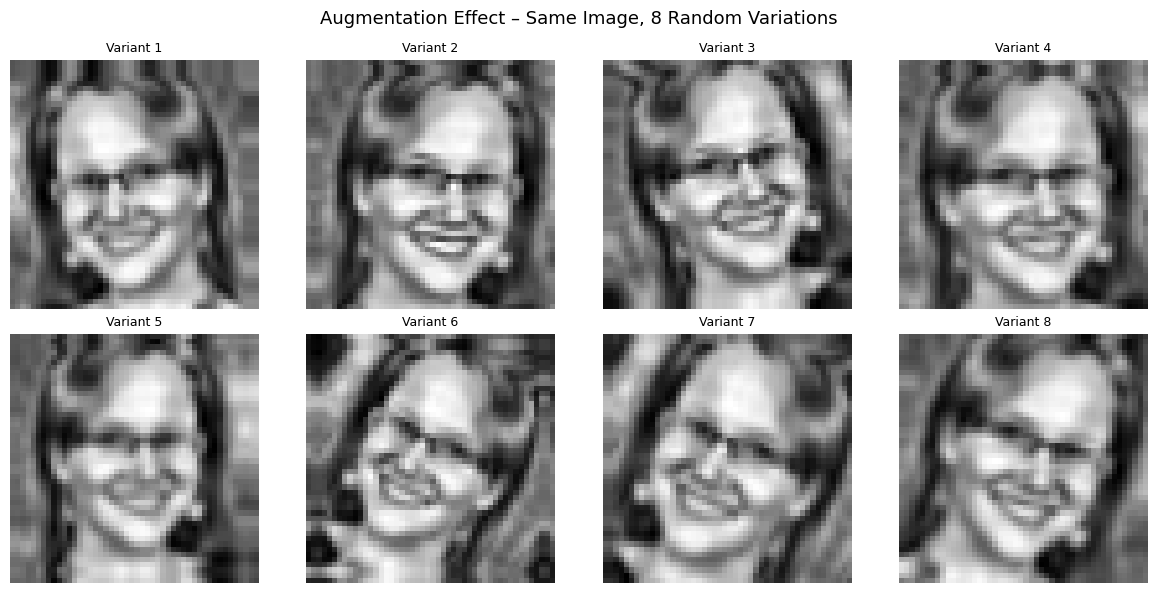

✅ Augmentation pipeline built


In [11]:
# ── Build augmentation layer ───────────────────────────────────────────────
augmentation = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),           # ±10 degrees
    layers.RandomZoom(0.10),               # ±10% zoom
    layers.RandomTranslation(0.05, 0.05),  # ±5% shift in x and y
    layers.RandomContrast(0.20),           # ±20% contrast
], name='augmentation')

# ── Wrap base model with augmentation for training ─────────────────────────
# Important: augmentation is applied INSIDE the model so it only runs during
# model.fit(), NOT during model.predict() or model.evaluate()
train_inputs = keras.Input(shape=(48, 48, 1))
augmented    = augmentation(train_inputs, training=True)
train_output = base_model(augmented)

train_model = keras.Model(train_inputs, train_output, name='FaceCode_Train')
train_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Visualise augmentation effect ─────────────────────────────────────────
# Pick one 'happy' face and show 8 augmented versions
happy_sample = X_train[y_train[:, 3].argmax()].reshape(1, 48, 48, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Augmentation Effect – Same Image, 8 Random Variations', fontsize=13)

for i, ax in enumerate(axes.flat):
    aug_img = augmentation(happy_sample, training=True).numpy()[0, :, :, 0]
    ax.imshow(aug_img, cmap='gray')
    ax.axis('off')
    ax.set_title(f'Variant {i+1}', fontsize=9)

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Augmentation pipeline built')

---
## Cell 9 – Set up training callbacks

Callbacks are functions that run automatically at the end of each epoch:

| Callback | What it does |
|---|---|
| **ModelCheckpoint** | Saves the model only when validation accuracy improves |
| **ReduceLROnPlateau** | Halves the learning rate if val_loss doesn't improve for 5 epochs |
| **EarlyStopping** | Stops training if val_accuracy doesn't improve for 15 epochs |
| **LRHistory** | Custom callback that records LR per epoch for the plot |

In [12]:
import os
os.makedirs('models', exist_ok=True)
os.makedirs('logs',   exist_ok=True)

MODEL_SAVE_PATH = 'models/emotion_cnn.keras'

# ── Custom callback to track learning rate ────────────────────────────────
class LRHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.lr_values = []
    def on_epoch_end(self, epoch, logs=None):
        lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        self.lr_values.append(lr)

lr_history = LRHistory()

callbacks = [
    # Save best model by val_accuracy
    keras.callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Reduce LR when validation loss plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,        # multiply LR by 0.5
        patience=5,        # wait 5 epochs before reducing
        min_lr=1e-6,
        verbose=1
    ),
    # Stop early if not improving
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    lr_history,
]

print('✅ Callbacks configured:')
print(f'   ModelCheckpoint → saves to: {MODEL_SAVE_PATH}')
print(f'   ReduceLROnPlateau → patience=5, factor=0.5')
print(f'   EarlyStopping → patience=15')

✅ Callbacks configured:
   ModelCheckpoint → saves to: models/emotion_cnn.keras
   ReduceLROnPlateau → patience=5, factor=0.5
   EarlyStopping → patience=15


---
## Cell 10 – TRAIN THE MODEL 🚀

This is the main training cell. Watch for:
- `val_accuracy` increasing over epochs (good)
- `EpochEnd: val_accuracy improved` messages (model is being saved)
- Learning rate reductions (model is fine-tuning)
- EarlyStopping trigger (training finished automatically)

**Expected output at end:** `val_accuracy ≈ 0.63–0.68`

In [13]:
EPOCHS     = 80
BATCH_SIZE = 64   # reduce to 32 if you get OOM errors on GPU

print('🚀 Starting training...')
print(f'   Max epochs : {EPOCHS}')
print(f'   Batch size : {BATCH_SIZE}')
print(f'   Train size : {len(X_train)}')
print(f'   Test size  : {len(X_test)}')
print(f'   Model will be saved to: {MODEL_SAVE_PATH}')
print('─' * 60)

history = train_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print('\n' + '─' * 60)
print('✅ Training complete!')
print(f'   Epochs trained : {len(history.history["accuracy"])}')
print(f'   Best val_acc   : {max(history.history["val_accuracy"]):.4f}')

🚀 Starting training...
   Max epochs : 80
   Batch size : 64
   Train size : 28709
   Test size  : 7178
   Model will be saved to: models/emotion_cnn.keras
────────────────────────────────────────────────────────────
Epoch 1/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.1502 - loss: 2.6265
Epoch 1: val_accuracy improved from None to 0.24115, saving model to models/emotion_cnn.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 136s 285ms/step - accuracy: 0.1524 - loss: 2.3988 - val_accuracy: 0.2412 - val_loss: 1.9414 - learning_rate: 0.0010
Epoch 2/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.1751 - loss: 2.0636
Epoch 2: val_accuracy did not improve from 0.24115
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 251ms/step - accuracy: 0.1878 - loss: 2.0157 - val_accuracy: 0.2364 - val_loss: 1.9409 - learning_rate: 0.0010
Epoch 3/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.2233 - loss: 1.9555
Epoch 3: val_accuracy improved from 0.24115 to 0.25704, saving model to models/emoti

---
## Cell 11 – Plot training curves

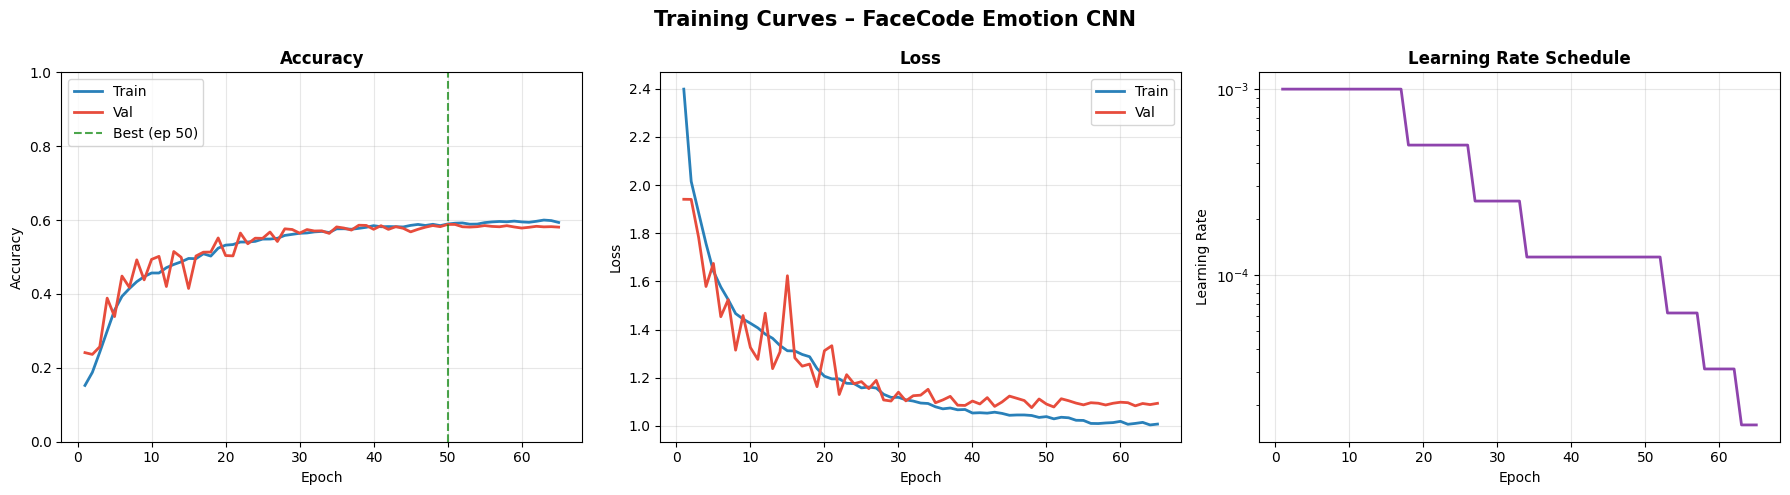

📊 Final metrics:
   Train accuracy : 0.5936 (59.4%)
   Val accuracy   : 0.5809 (58.1%)
   Best val acc   : 0.5883 (epoch 50)


In [14]:
hist = history.history
epochs_range = range(1, len(hist['accuracy']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves – FaceCode Emotion CNN', fontsize=15, fontweight='bold')

# ── Plot 1: Accuracy ───────────────────────────────────────────────────────
axes[0].plot(epochs_range, hist['accuracy'],     label='Train', color='#2980b9', linewidth=2)
axes[0].plot(epochs_range, hist['val_accuracy'], label='Val',   color='#e74c3c', linewidth=2)
best_epoch = hist['val_accuracy'].index(max(hist['val_accuracy'])) + 1
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (ep {best_epoch})')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(alpha=0.3)

# ── Plot 2: Loss ───────────────────────────────────────────────────────────
axes[1].plot(epochs_range, hist['loss'],     label='Train', color='#2980b9', linewidth=2)
axes[1].plot(epochs_range, hist['val_loss'], label='Val',   color='#e74c3c', linewidth=2)
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Plot 3: Learning rate ──────────────────────────────────────────────────
axes[2].plot(epochs_range, lr_history.lr_values, color='#8e44ad', linewidth=2)
axes[2].set_title('Learning Rate Schedule', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'📊 Final metrics:')
print(f'   Train accuracy : {hist["accuracy"][-1]:.4f} ({hist["accuracy"][-1]*100:.1f}%)')
print(f'   Val accuracy   : {hist["val_accuracy"][-1]:.4f} ({hist["val_accuracy"][-1]*100:.1f}%)')
print(f'   Best val acc   : {max(hist["val_accuracy"]):.4f} (epoch {best_epoch})')

---
## Cell 12 – Evaluate: confusion matrix and per-class accuracy

The confusion matrix shows which emotions the model confuses.
For FER2013 it's normal to see 'disgust' confused with 'angry' —
they look very similar in still images.

🔄 Running predictions on test set...

✅ Overall test accuracy: 0.5883 (58.8%)

📋 Per-class report:
              precision    recall  f1-score   support

       angry       0.49      0.53      0.51       958
     disgust       0.24      0.77      0.36       111
        fear       0.48      0.29      0.37      1024
       happy       0.87      0.78      0.82      1774
         sad       0.52      0.38      0.44      1247
    surprise       0.65      0.78      0.71       831
     neutral       0.49      0.67      0.57      1233

    accuracy                           0.59      7178
   macro avg       0.54      0.60      0.54      7178
weighted avg       0.60      0.59      0.58      7178



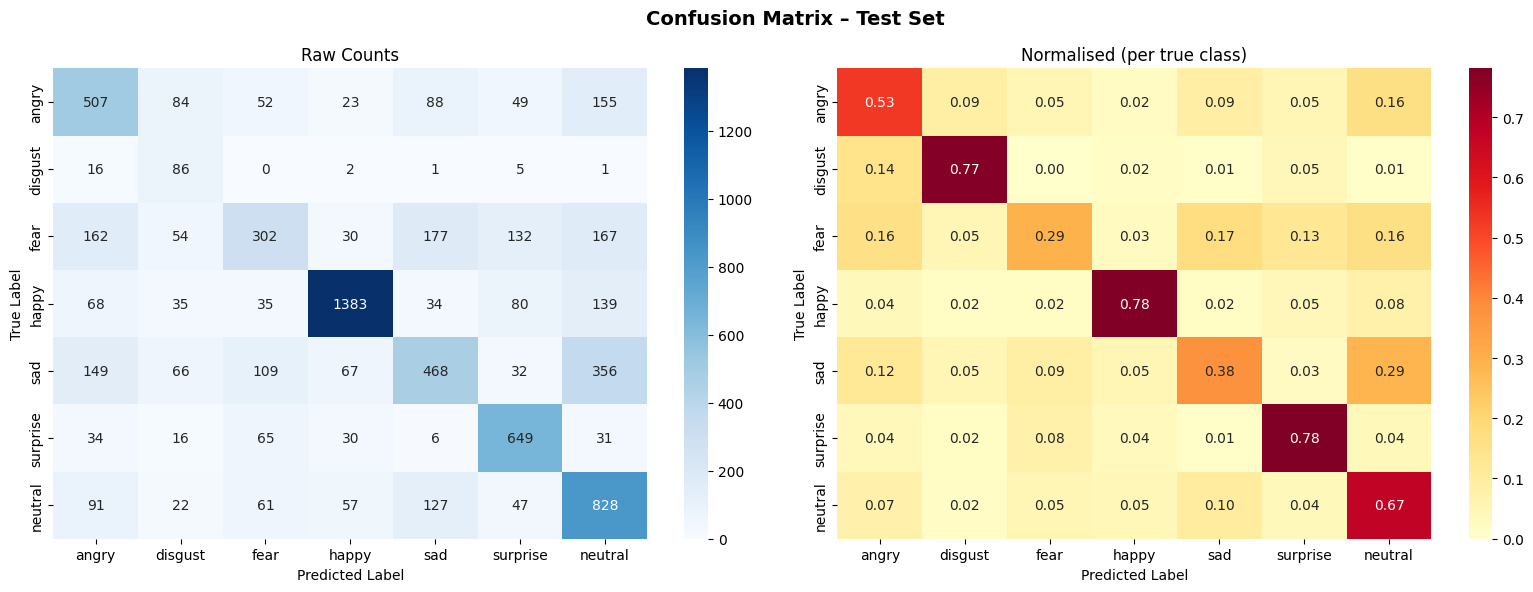

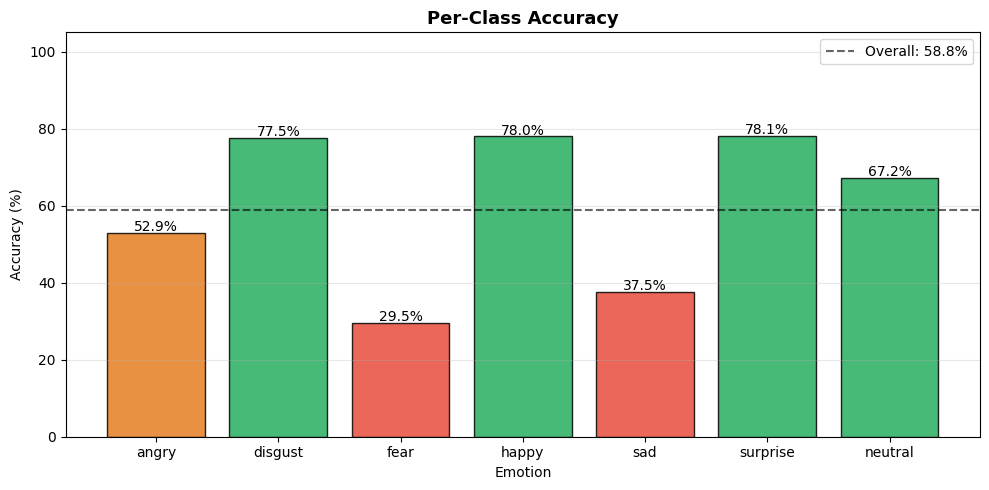

In [15]:
# ── Load the best saved model for evaluation ───────────────────────────────
best_model = keras.models.load_model(MODEL_SAVE_PATH)

# ── Predictions ────────────────────────────────────────────────────────────
print('🔄 Running predictions on test set...')
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

overall_acc = np.mean(y_pred == y_true)
print(f'\n✅ Overall test accuracy: {overall_acc:.4f} ({overall_acc*100:.1f}%)')

# ── Classification report ──────────────────────────────────────────────────
print('\n📋 Per-class report:')
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS))

# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_normalised = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix – Test Set', fontsize=14, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalised
sns.heatmap(cm_normalised, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, ax=axes[1])
axes[1].set_title('Normalised (per true class)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Per-class accuracy bar chart ───────────────────────────────────────────
per_class_acc = cm_normalised.diagonal()
colors = ['#27ae60' if a >= 0.6 else '#e67e22' if a >= 0.4 else '#e74c3c'
          for a in per_class_acc]

plt.figure(figsize=(10, 5))
bars = plt.bar(EMOTION_LABELS, per_class_acc * 100, color=colors, edgecolor='black', alpha=0.85)
plt.axhline(y=overall_acc * 100, color='black', linestyle='--', alpha=0.6,
            label=f'Overall: {overall_acc*100:.1f}%')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{acc*100:.1f}%', ha='center', fontsize=10)
plt.title('Per-Class Accuracy', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Emotion')
plt.ylim([0, 105])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Cell 13 – Visualise wrong predictions

Shows images where the model predicted wrong.
This helps understand what kinds of faces are hardest to classify.

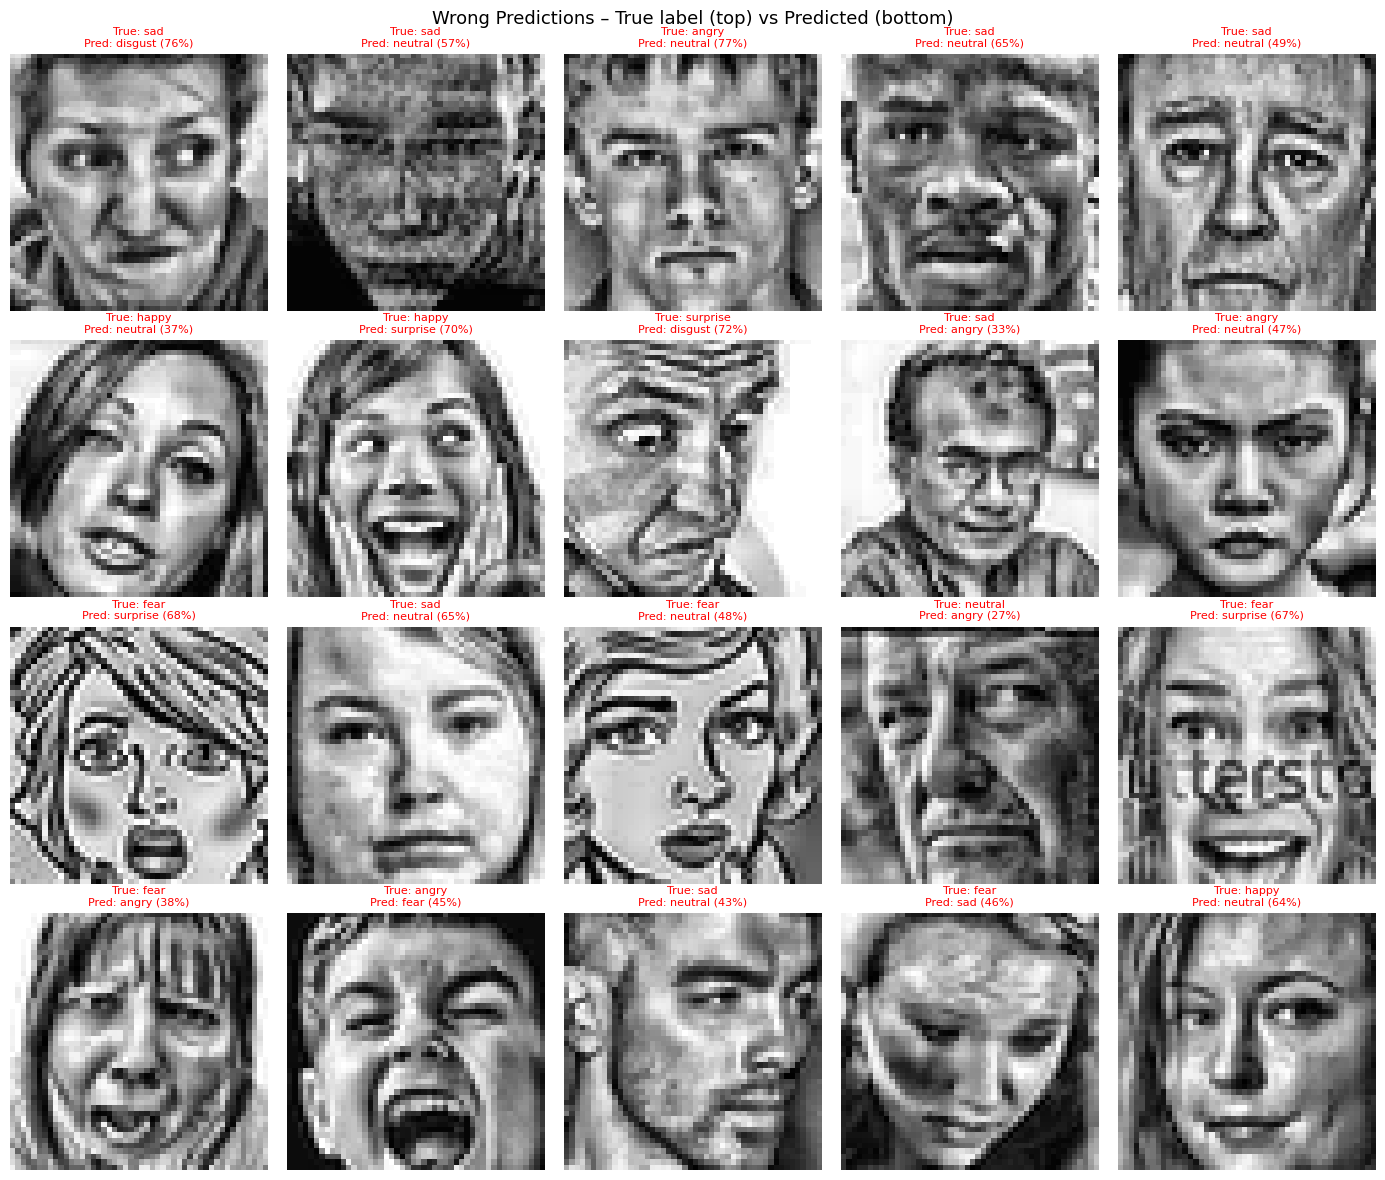

Total wrong predictions: 2955 / 7178 (41.2%)


In [16]:
wrong_indices = np.where(y_pred != y_true)[0]
sample_wrong = np.random.choice(wrong_indices, min(20, len(wrong_indices)), replace=False)

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.suptitle('Wrong Predictions – True label (top) vs Predicted (bottom)', fontsize=13)

for i, idx in enumerate(sample_wrong):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test[idx].reshape(48, 48), cmap='gray')
    true_label = EMOTION_LABELS[y_true[idx]]
    pred_label = EMOTION_LABELS[y_pred[idx]]
    confidence = y_pred_probs[idx][y_pred[idx]]
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.0%})',
                fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wrong_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Total wrong predictions: {len(wrong_indices)} / {len(y_true)} ({len(wrong_indices)/len(y_true)*100:.1f}%)')

---
## Cell 14 – Save model and download

The model is already saved to `models/emotion_cnn.keras` by ModelCheckpoint.
This cell downloads it to your computer and also saves a summary JSON.

In [18]:
import os
import json

# ── Verify model file exists ───────────────────────────────────────────────
model_size = os.path.getsize(MODEL_SAVE_PATH) / 1e6
print(f'✅ Model file: {MODEL_SAVE_PATH}')
print(f'   File size  : {model_size:.1f} MB')

# ── Save training summary JSON ─────────────────────────────────────────────
summary = {
    'model_path':         MODEL_SAVE_PATH,
    'epochs_trained':     len(hist['accuracy']),
    'best_val_accuracy':  float(max(hist['val_accuracy'])),
    'final_val_accuracy': float(hist['val_accuracy'][-1]),
    'final_train_accuracy': float(hist['accuracy'][-1]),
    'per_class_accuracy': {e: float(a) for e, a in zip(EMOTION_LABELS, per_class_acc)},
    'total_params':       base_model.count_params(),
    'emotion_labels':     EMOTION_LABELS,
    'training_config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'optimizer': 'Adam',
        'initial_lr': 1e-3,
        'class_weights': {str(k): float(v) for k, v in class_weights.items()},
        'augmentation': ['RandomFlip', 'RandomRotation', 'RandomZoom',
                         'RandomTranslation', 'RandomContrast'],
        'preprocessing': 'CLAHE + normalise 0-1'
    }
}

with open('models/training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\n📊 Training summary:')
for k, v in summary.items():
    if k not in ('per_class_accuracy', 'training_config', 'emotion_labels'):
        print(f'   {k}: {v}')
print('\n📈 Per-class accuracy:')
for emotion, acc in summary['per_class_accuracy'].items():
    bar = '█' * int(acc * 20)
    print(f'   {emotion:10} {acc*100:5.1f}%  {bar}')

✅ Model file: models/emotion_cnn.keras
   File size  : 15.1 MB

📊 Training summary:
   model_path: models/emotion_cnn.keras
   epochs_trained: 65
   best_val_accuracy: 0.5883254408836365
   final_val_accuracy: 0.5809417963027954
   final_train_accuracy: 0.5936117768287659
   total_params: 1244135

📈 Per-class accuracy:
   angry       52.9%  ██████████
   disgust     77.5%  ███████████████
   fear        29.5%  █████
   happy       78.0%  ███████████████
   sad         37.5%  ███████
   surprise    78.1%  ███████████████
   neutral     67.2%  █████████████

⬇️  Downloading emotion_cnn.keras to your computer...


NameError: name 'files' is not defined

---
## Cell 15 – Quick inference test

Verifies the saved model loads correctly and runs predictions.
Run this to confirm everything works before integrating into FaceCode.

✅ Model reloaded from models/emotion_cnn.keras
Sample 1: True=angry      | Pred=sad        | Conf=0.38 ❌
Sample 2: True=fear       | Pred=surprise   | Conf=0.56 ❌
Sample 3: True=neutral    | Pred=neutral    | Conf=0.53 ✅
Sample 4: True=neutral    | Pred=neutral    | Conf=0.46 ✅
Sample 5: True=sad        | Pred=neutral    | Conf=0.54 ❌
Sample 6: True=sad        | Pred=neutral    | Conf=0.36 ❌
Sample 7: True=angry      | Pred=angry      | Conf=0.51 ✅
Sample 8: True=surprise   | Pred=surprise   | Conf=0.64 ✅
Sample 9: True=angry      | Pred=angry      | Conf=0.58 ✅
Sample 10: True=surprise   | Pred=neutral    | Conf=0.33 ❌


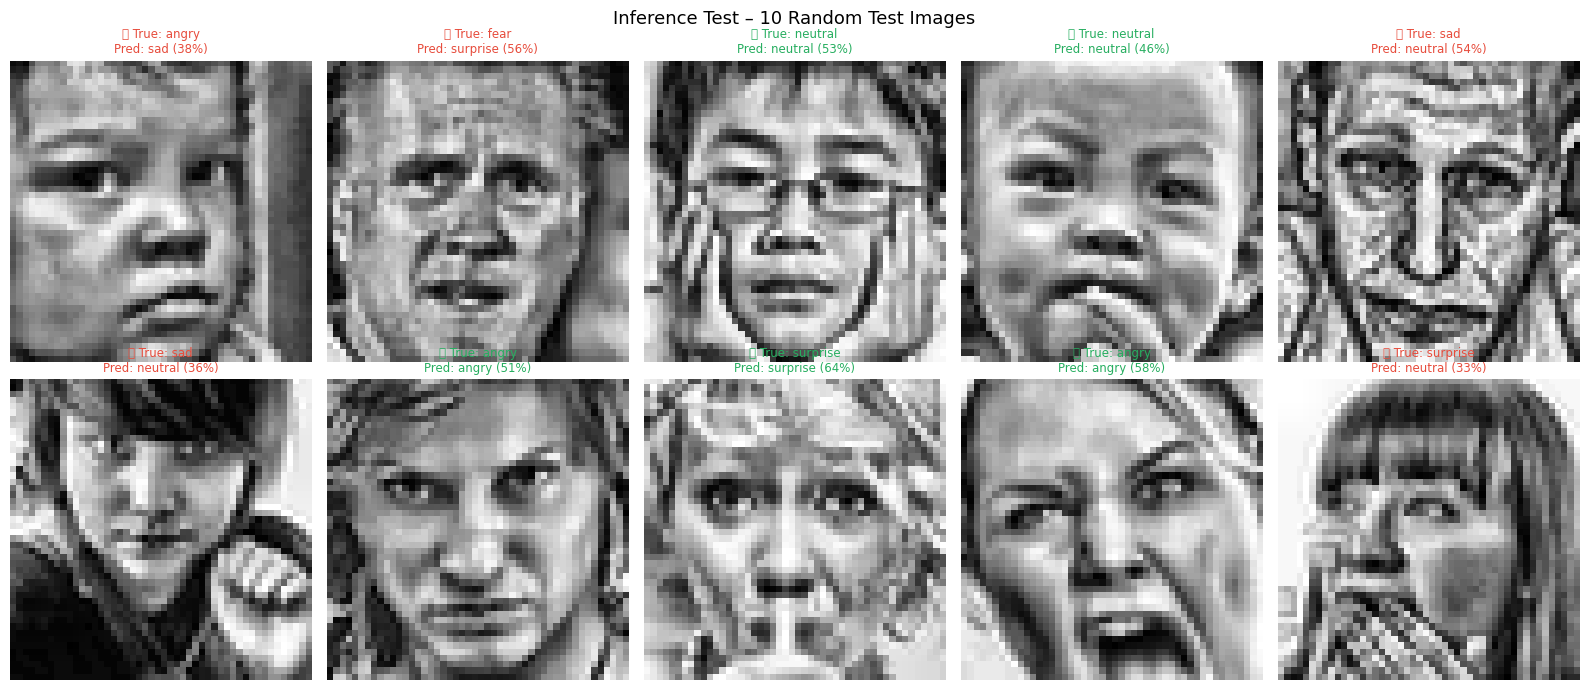


✅ Model is working correctly and ready for FaceCode integration!
   Next step: place emotion_cnn.keras in facecode/models/


In [19]:
# ── Reload model from disk (same as FaceCode will do) ──────────────────────
loaded_model = keras.models.load_model(MODEL_SAVE_PATH)
print(f'✅ Model reloaded from {MODEL_SAVE_PATH}')

# ── Test on 10 random test images ─────────────────────────────────────────
test_indices = np.random.choice(len(X_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Inference Test – 10 Random Test Images', fontsize=13)

for i, idx in enumerate(test_indices):
    img = X_test[idx]
    true_label = EMOTION_LABELS[np.argmax(y_test[idx])]

    # Run inference
    probs = loaded_model.predict(img.reshape(1, 48, 48, 1), verbose=0)[0]
    pred_label = EMOTION_LABELS[np.argmax(probs)]
    confidence = np.max(probs)
    correct = pred_label == true_label

    ax = axes[i // 5][i % 5]
    ax.imshow(img.reshape(48, 48), cmap='gray')
    color = '#27ae60' if correct else '#e74c3c'
    icon  = '✅' if correct else '❌'
    ax.set_title(
        f'{icon} True: {true_label}\nPred: {pred_label} ({confidence:.0%})',
        fontsize=8.5, color=color
    )
    ax.axis('off')

    # Also print probability bar for each emotion
    print(f'Sample {i+1}: True={true_label:10} | Pred={pred_label:10} | Conf={confidence:.2f} {icon}')

plt.tight_layout()
plt.savefig('inference_test.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n✅ Model is working correctly and ready for FaceCode integration!')
print('   Next step: place emotion_cnn.keras in facecode/models/')